<a href="https://colab.research.google.com/github/ahmadfa100/-Ahmad-bani-Hamad/blob/main/Copy_of_CNN_model_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Unzipd the the data set:
!unzip -o -q archive.zip -d /content/

In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import models, layers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
class Config:
    image_height = 224
    image_width = 224
    channels = 3
    batch_size = 32
    epochs = 45
    learning_rate = 0.0001
    classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
    num_classes = len(classes)
    MODEL_SAVE_PATH = '/content/flower_model.keras'
    HISTORY_SAVE_PATH = '/content/training_history.npy'
    BASE_DIR = '/content/flower_split'

In [ ]:
# Setup our variables

class Config:
    image_height = 224
    image_width = 224
    channels = 3
    batch_size = 32
    epochs = 60
    learning_rate = 0.0001
    classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
    num_classes = len(classes)
    #بسبب كثرة المشاكل بخصوص الداتا وتحميلها اضطريت اضيف الباث من جديد هنا
    BASE_DIR = '/content/flower_split'
    MODEL_SAVE_PATH = '/content/flower_model.keras'
    HISTORY_SAVE_PATH = '/content/training_history.npy'

In [ ]:
# partitioning the data since the data set is not divided as we want
def prepare_data(source_dir, config):
    if os.path.exists(config.BASE_DIR): # بعد محاولات عديدة كان لازم اضيف هذا
        print("Alread partitioned")
        return

    for split in ['train', 'validation', 'test']:
        for cls in config.classes:
            os.makedirs(os.path.join(config.BASE_DIR, split, cls), exist_ok=True)

    for cls in config.classes:
        cls_path = os.path.join(source_dir, cls)
        if not os.path.exists(cls_path):
            print(f"ُError , colun't find {cls_path}")
            continue

        images = os.listdir(cls_path)
        np.random.shuffle(images)

        train_idx = int(len(images) * 0.7)
        val_idx = int(len(images) * 0.9)

        for i, img in enumerate(images):
            src = os.path.join(cls_path, img)
            if i < train_idx:
                shutil.copy(src, os.path.join(config.BASE_DIR, 'train', cls, img))
            elif i < val_idx:
                shutil.copy(src, os.path.join(config.BASE_DIR, 'validation', cls, img))
            else:
                shutil.copy(src, os.path.join(config.BASE_DIR, 'test', cls, img))
    print("Sucessfuly partitioned the data ")

In [ ]:
# the input stage: where we give the model our image with more than one corenr
def create_data_generators(config):
    TRAIN_DIR = os.path.join(config.BASE_DIR, 'train')
    VAL_DIR = os.path.join(config.BASE_DIR, 'validation')
    TEST_DIR = os.path.join(config.BASE_DIR, 'test')

    train_datagen = ImageDataGenerator(
        rescale=1./255, rotation_range=20, width_shift_range=0.2,
        height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
        horizontal_flip=True, fill_mode='nearest'
    )
    val_test_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=(config.image_height, config.image_width),
        batch_size=config.batch_size, class_mode='categorical', shuffle=True
    )
    val_gen = val_test_datagen.flow_from_directory(
        VAL_DIR, target_size=(config.image_height, config.image_width),
        batch_size=config.batch_size, class_mode='categorical', shuffle=False
    )
    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR, target_size=(config.image_height, config.image_width),
        batch_size=config.batch_size, class_mode='categorical', shuffle=False
    )
    return train_gen, val_gen, test_gen

In [ ]:
# My CNN Model!
def build_cnn_model(config):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(config.image_height, config.image_width, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.4),

        #new one
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(config.num_classes, activation='softmax') # It's softmax because we want to conver tht
                                                                # classes to propelties.
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config.learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
#callback : for saveing best version
def create_callbacks(config):
    return [
        callbacks.ModelCheckpoint(config.MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    ]

In [ ]:
#Drawing
def plot_metrics(history):

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def predict_and_analyze(model, test_gen, config):
    print("\n--- التنبؤ على بيانات الاختبار وإصدار التقرير ---")
    y_pred_prob = model.predict(test_gen)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_gen.classes

    print("\nتقرير التصنيف (Classification Report):")
    print(classification_report(y_true, y_pred, target_names=config.classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=config.classes, yticklabels=config.classes)
    plt.title('مصفوفة الارتباك (Confusion Matrix)')
    plt.xlabel('الفئة المتوقعة (Predicted)')
    plt.ylabel('الفئة الحقيقية (Actual)')
    plt.show()

In [ ]:
def main():
    print("\n" + "="*60)
    print("Starting CNN Model ")
    print("="*60 + "\n")

    config = Config()

    # 1. prepare the data
    prepare_data('/content/train', config)

    # 2.Data image generator
    train_gen, val_gen, test_gen = create_data_generators(config)

    # 3. Constructor the model
    model = build_cnn_model(config)
    model.summary() # لعرض هيكل النموذج

    # 4.Offical trying
    print("\n🚀 بدء التدريب ...")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=config.epochs,
        callbacks=create_callbacks(config),
        verbose=1
    )

    # 5. the assessment and drawing
    print("\n📊 تقييم النموذج على بيانات الاختبار ...")
    test_loss, test_acc = model.evaluate(test_gen)
    print(f"Test Accuracy: {test_acc*100:.2f}%\n")

    plot_metrics(history)
    predict_and_analyze(model, test_gen, config)


🚀 بدء مشروع تصنيف الزهور باستخدام شبكات CNN

Alread partitioned
Found 1919 images belonging to 5 classes.
Found 550 images belonging to 5 classes.
Found 277 images belonging to 5 classes.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,813,637 (25.99 MB)

 Trainable params: 6,812,677 (25.99 MB)

 Non-trainable params: 960 (3.75 KB)


🚀 بدء التدريب ...
Epoch 1/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.2465 - loss: 2.8865
Epoch 1: val_accuracy improved from None to 0.26182, saving model to /content/flower_model.keras

Epoch 1: finished saving model to /content/flower_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 53s 706ms/step - accuracy: 0.2767 - loss: 2.0737 - val_accuracy: 0.2618 - val_loss: 5.2920 - learning_rate: 1.0000e-04
Epoch 2/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.3204 - loss: 1.5202
Epoch 2: val_accuracy did not improve from 0.26182
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 492ms/step - accuracy: 0.3205 - loss: 1.5204 - val_accuracy: 0.2618 - val_loss: 6.7535 - learning_rate: 1.0000e-04
Epoch 3/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.3396 - loss: 1.5154
Epoch 3: val_accuracy did not improve from 0.26182
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 507ms/step - accuracy: 0.3445 - loss: 1.5005 - val_accuracy: 0.2382 - val_loss: 8.0291 - learning_rate: 1.0000e-04
Epoch 4/60
60/60 ━━━━━━

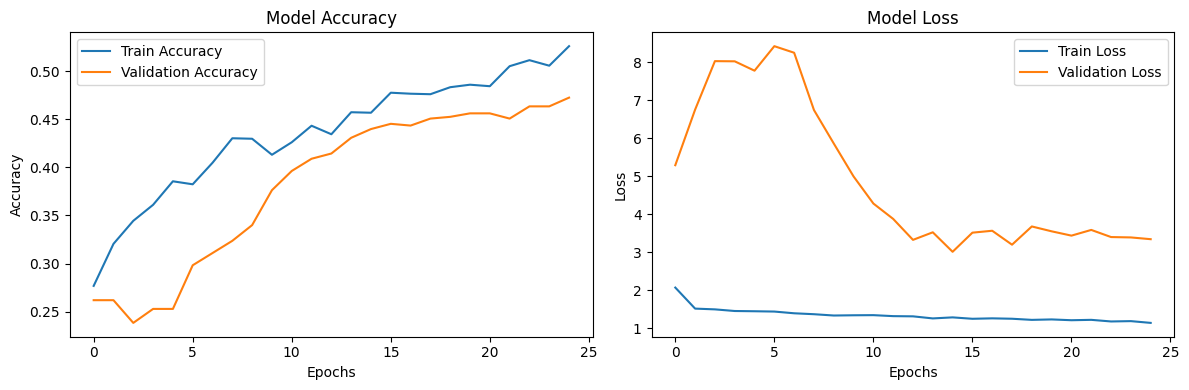


--- التنبؤ على بيانات الاختبار وإصدار التقرير ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step

تقرير التصنيف (Classification Report):
              precision    recall  f1-score   support

       daisy       0.57      0.08      0.14        51
   dandelion       0.33      0.82      0.47        65
        rose       0.62      0.36      0.46        50
   sunflower       0.57      0.66      0.61        50
       tulip       0.62      0.21      0.32        61

    accuracy                           0.44       277
   macro avg       0.54      0.43      0.40       277
weighted avg       0.53      0.44      0.40       277



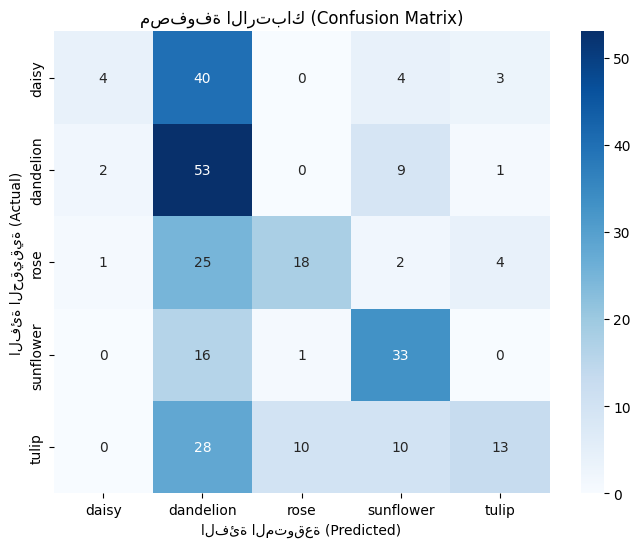

In [ ]:
#run the model:
if __name__ == "__main__":
    main()

In [ ]:
from tensorflow.keras import models, layers
import tensorflow as tf

def build_cnn_model(config):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(config.image_height, config.image_width, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.4),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(config.num_classes, activation='softmax') # 5 وحدات
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config.learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# CallBack
def create callbacks():
return [
callbacks.ModelCheckpoint(config.MODEL_SAVE_PATH, monitor='val_accuracy', sav
callbacks. ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_l
callbacks. EarlyStopping(monitor='val_loss', patience=10, restore_best_weights
callbacks.CSVLogger('training_log.csv'),

]

def train_model(model, train_gen, val_gen, cb_list):
print("\n& بدء التدريب ... \n")
history = model.fit(
train_gen,
epochs=config. EPOCHS,
validation_data=val_gen,
callbacks=cb_list,
verbose=1
I

np.save(config.HISTORY_SAVE_PATH, history.history)
return history


                     def evaluate_model(model, test_gen):
print("n تقييم النموذج ... \n")
test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(test
print(f"\n Liil:\nAccuracy: {test_acc :. 4f}\nLoss: {test_loss :. 4f}\nPrecision:
return test acc

def predict_and_analyze(model, test_gen):
print("\n التنبؤ على بيانات الاختبار ... In")

التنبؤ بالقئات #
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen. classes

تقرير التصنيف #
(":تقرير التصنيف print("\n
print(classification_report(y_true, y_pred, target_names=config.CLASSES))

مصفوفة الارتباك #
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',

            cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=config.CLASSES,
yticklabels=config.CLASSES)
plt.title('m مصفوفة الارتباك (confusion Matrix)')
('الفلة المتوقعة ') plt.xlabel
(' الفئة الحقيقية")plt.ylabel
plt.show()


 def main():
print("\n" + "="*60)
("من صور الأشعة السينية 19-COVID للكشف عن CNN نموذج")print
print("="*60 + "\n")

فك الضغط #
extract_rar_dataset()

تحضير البيانات #
train_gen, val_gen, test_gen = create_data_generators()

بناء وتجميع النموذج #
model = compile_model(build_cnn_model())

التدريب #


 بناء وتجميع النموذج #
model = compile_model(build_cnn_model())

التدريب #
history = train_model(model, train_gen, val_gen, create_callbacks())

التقييم #
evaluate_model(model, test_gen)
#predict
predict_and_analyze(model, test_gen)

حفظ النموذج #
model.save(config.MODEL_SAVE_PATH)
print(f"\n تم حفظ النموذج في:{config.MODEL_SAVE_PATH}")

 #

#
#

تشغيل البرنامج

if

name
main()

==

main

":

I

من صور الأشعة السينية 19-COVID للكشف عن CNN نموذج
config = Config()
train_gen, val_gen, test_gen = create_data_generators(config)

# 2. بناء النموذج
model = build_cnn_model(config)

# 3. بدء عملية التدريب (Training)
print("Model traing")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config.epochs
)

# 4. تقييم النموذج على بيانات الاختبار (Evaluation)
print("\n Model assessment")
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Found 0 images belonging to 5 classes.
Found 0 images belonging to 5 classes.
Found 0 images belonging to 5 classes.
Model traing


ValueError: The PyDataset has length 0

NameError: name 'history' is not defined

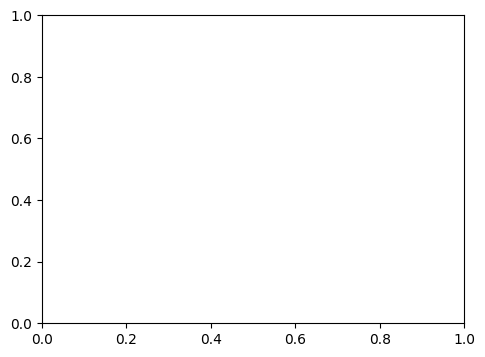

In [ ]:
import matplotlib.pyplot as plt

# رسم مخطط الدقة (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# رسم مخطط الخسارة (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
import shutil
# مسح المجلد القديم للتأكد من إعادة التقسيم من الصفر
if os.path.exists('/content/flower_split'):
    shutil.rmtree('/content/flower_split')
    print("تم مسح المجلد القديم، الآن أعد تشغيل الكود الرئيسي.")

تم مسح المجلد القديم، الآن أعد تشغيل الكود الرئيسي.
